# House Price Regression

This notebook builds a regression workflow for house price prediction with feature engineering, missing-value handling, model comparison, residual analysis, and a saved prediction pipeline.

In [5]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from dataclasses import dataclass

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import TransformedTargetRegressor

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)

DATA_PATH = Path('data.csv')
MODEL_PATH = Path('house_price_model.joblib')
RANDOM_STATE = 42

Dataset shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


,missing_count
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.0,460943.461539,654962.5,26590000.0


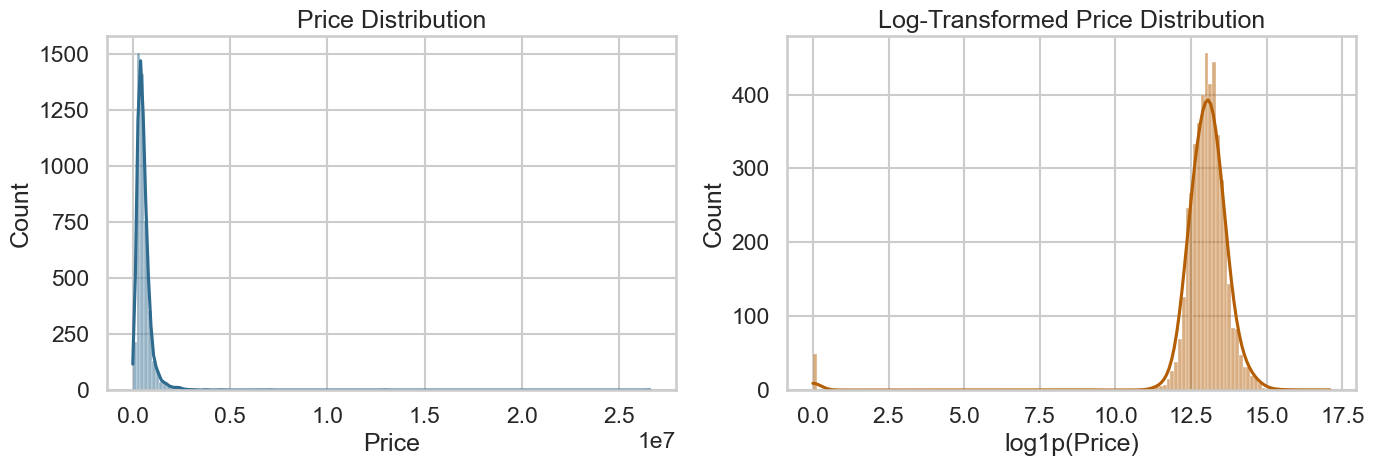

In [6]:
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
display(df.head())

missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame('missing_count'))

numeric_preview = df.select_dtypes(include='number').describe().T
if 'price' in numeric_preview.index:
    display(numeric_preview.loc[['price']])
else:
    display(numeric_preview.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], kde=True, ax=axes[0], color='#2f6b8f')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')

sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1], color='#b45f06')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log1p(Price)')
plt.tight_layout()

In [7]:
class HouseFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        frame = pd.DataFrame(X).copy()
        frame.columns = [str(column) for column in frame.columns]

        frame['date'] = pd.to_datetime(frame.get('date'), errors='coerce')
        sale_year = frame['date'].dt.year
        sale_month = frame['date'].dt.month
        sale_day = frame['date'].dt.day

        frame['sale_year'] = sale_year
        frame['sale_month'] = sale_month
        frame['sale_day'] = sale_day
        frame['house_age'] = sale_year - pd.to_numeric(frame.get('yr_built'), errors='coerce')
        frame['is_renovated'] = (pd.to_numeric(frame.get('yr_renovated'), errors='coerce').fillna(0) > 0).astype(int)

        renovated_year = pd.to_numeric(frame.get('yr_renovated'), errors='coerce')
        frame['renovation_age'] = np.where(
            renovated_year.fillna(0) > 0,
            sale_year - renovated_year,
            frame['house_age']
        )

        frame['total_rooms_proxy'] = pd.to_numeric(frame.get('bedrooms'), errors='coerce') + pd.to_numeric(frame.get('bathrooms'), errors='coerce')
        frame['living_to_lot_ratio'] = pd.to_numeric(frame.get('sqft_living'), errors='coerce') / (pd.to_numeric(frame.get('sqft_lot'), errors='coerce') + 1)

        drop_columns = ['date', 'street', 'country', 'yr_built', 'yr_renovated']
        frame = frame.drop(columns=drop_columns, errors='ignore')
        return frame


feature_engineer = HouseFeatureEngineer()
skewed_numeric_features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'living_to_lot_ratio']
regular_numeric_features = [
    'bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition',
    'sale_year', 'sale_month', 'sale_day', 'house_age', 'is_renovated',
    'renovation_age', 'total_rooms_proxy'
]
categorical_features = ['city', 'statezip']

skewed_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler()),
])

regular_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('skewed', skewed_numeric_pipeline, skewed_numeric_features),
    ('numeric', regular_numeric_pipeline, regular_numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
])


def build_pipeline(regressor):
    model_pipeline = Pipeline([
        ('feature_engineer', feature_engineer),
        ('preprocess', preprocessor),
        ('regressor', regressor),
    ])
    return TransformedTargetRegressor(
        regressor=model_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

In [9]:
target = df['price']
features = df.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

model_specs = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
trained_models = {}

for name, regressor in model_specs.items():
    model = build_pipeline(regressor)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
print(f'Best model: {best_model_name}')

,Model,RMSE,MAE,R2
0,Linear Regression,9.932632e+05,196247.987314,0.032627
1,Gradient Boosting,9.975878e+05,193443.217499,0.024185
2,Random Forest,1.004440e+06,194978.226727,0.010735


Best model: Linear Regression


Residual summary:
count    9.200000e+02
mean     1.180382e+05
std      9.867609e+05
min     -1.202706e+06
25%     -3.810852e+04
50%      3.952694e+04
75%      1.435266e+05
max      2.637857e+07
Name: price, dtype: float64


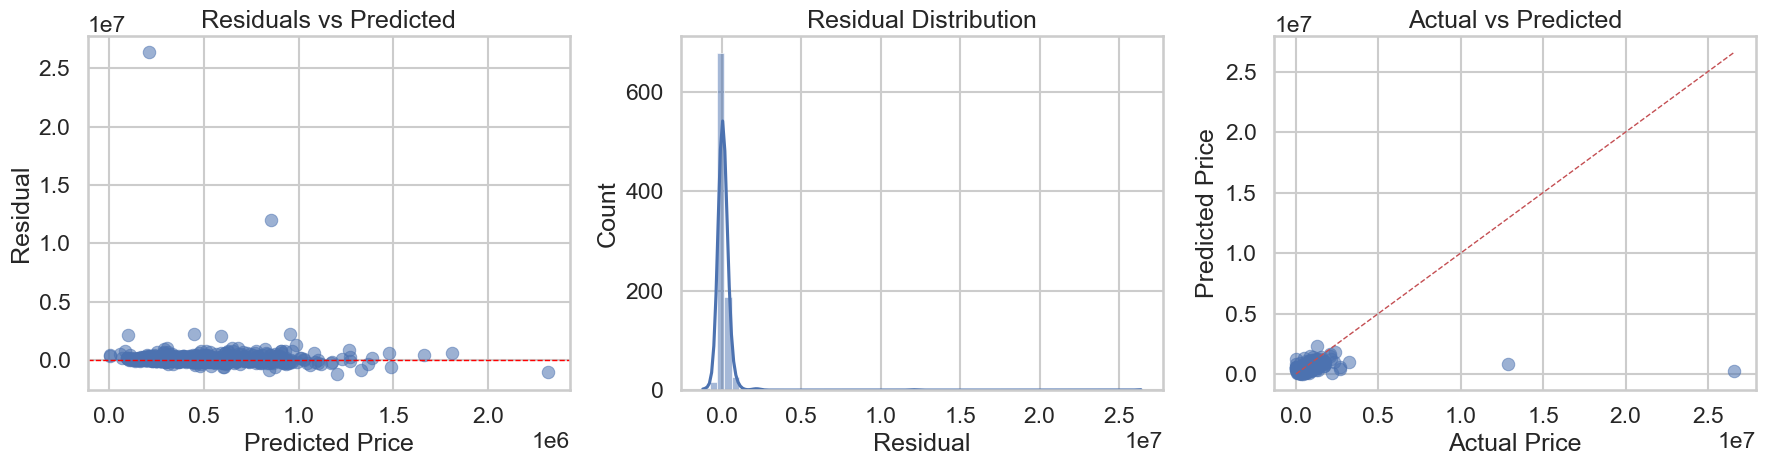

In [10]:
best_predictions = best_model.predict(X_test)
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=best_predictions, y=residuals, ax=axes[0], alpha=0.55, edgecolor=None)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, kde=True, ax=axes[1], color='#4c72b0')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

sns.scatterplot(x=y_test, y=best_predictions, ax=axes[2], alpha=0.55, edgecolor=None)
min_price = min(y_test.min(), best_predictions.min())
max_price = max(y_test.max(), best_predictions.max())
axes[2].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=1)
axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')

plt.tight_layout()

print('Residual summary:')
print(pd.Series(residuals).describe())

In [11]:
joblib.dump(best_model, MODEL_PATH)
print(f'Saved model to: {MODEL_PATH.resolve()}')

sample_house = pd.DataFrame([
    {
        'date': '2014-05-02 00:00:00',
        'price': 0,
        'bedrooms': 3,
        'bathrooms': 2.0,
        'sqft_living': 1800,
        'sqft_lot': 7500,
        'floors': 1.0,
        'waterfront': 0,
        'view': 0,
        'condition': 4,
        'sqft_above': 1800,
        'sqft_basement': 0,
        'yr_built': 1995,
        'yr_renovated': 0,
        'street': '123 Example St',
        'city': 'Seattle',
        'statezip': 'WA 98115',
        'country': 'USA',
    }
])

sample_prediction = best_model.predict(sample_house)[0]
print(f'Predicted price for the sample house: ${sample_prediction:,.0f}')

Saved model to: C:\Users\HP\Jupyter\InternShala_ML\HousePred\house_price_model.joblib
Predicted price for the sample house: $579,684


## Prediction Usage

After running the notebook, load the saved `house_price_model.joblib` file with `joblib.load(...)`. Pass a one-row pandas DataFrame containing the raw house columns used in the sample prediction cell, then call `.predict(...)` to get the estimated price.